# Autoencoders for Anomaly Detection

### Step 1 - Data Preparation

#### Importing Packages

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch 
from torchinfo import summary
import torch.nn as nn   
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.dates as mdates
import torch.optim as optim
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, f1_score


#### Device

In [56]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cpu


#### Seed

If we don't fix seeds, our model gives slightly different results each run, making it impossible to compare experiments fairly

In [57]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

#### Loading the dataset

In [58]:
df = pd.read_csv('/Users/mogankumarnarsozhan/Desktop/Transformers/ec2_cpu_utilization_ac20cd.csv')
df.head()

,timestamp,value
0,2014-04-02 14:29:00,42.652
1,2014-04-02 14:34:00,41.362
2,2014-04-02 14:39:00,43.408
3,2014-04-02 14:44:00,40.262
4,2014-04-02 14:49:00,40.328


In [59]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)         # the auto encoder must see the data in chronological order. Thats why we sort it.
df.head()

,timestamp,value
0,2014-04-02 14:29:00,42.652
1,2014-04-02 14:34:00,41.362
2,2014-04-02 14:39:00,43.408
3,2014-04-02 14:44:00,40.262
4,2014-04-02 14:49:00,40.328


In [60]:
df.shape

(4032, 2)

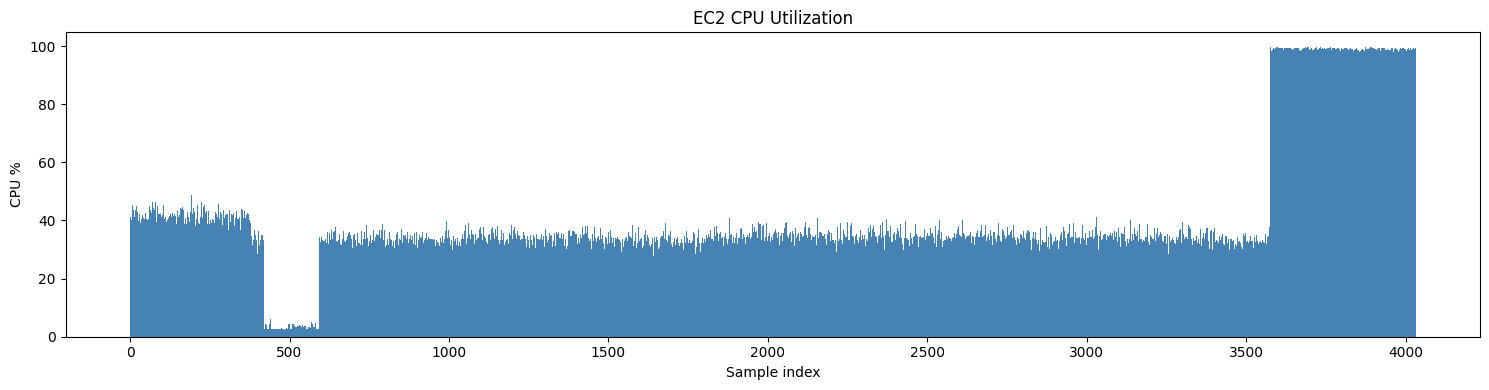

In [61]:
plt.figure(figsize=(15, 4))
plt.bar(df.index, df['value'], color='steelblue', width=1.0)
plt.xlabel('Sample index')
plt.ylabel('CPU %')
plt.title('EC2 CPU Utilization')
plt.tight_layout()
plt.savefig('cpu_bar.png', dpi=150)
plt.show()

### Step 2 - Pre Processing

#### Normalizing

In [62]:
normal_mask = df['value'] < 50

# Initializing the MinMax Scaler
scaler = MinMaxScaler(feature_range=(0,1))

# Find the min and max numbers
scaler.fit(df.loc[normal_mask , ['value']])

# Apply the scaling formula
df['value_scaled'] = scaler.transform(df[['value']])

In [63]:
print(f"Normal range after scaling: "
      f"{df.loc[normal_mask, 'value_scaled'].min():.3f} - "
      f"{df.loc[normal_mask, 'value_scaled'].max():.3f}")
print(f"Anomaly range after scaling: "
      f"{df.loc[~normal_mask, 'value_scaled'].min():.3f} - "
      f"{df.loc[~normal_mask, 'value_scaled'].max():.3f}")

Normal range after scaling: 0.000 - 1.000
Anomaly range after scaling: 1.083 - 2.101


#### Create Sliding Windows

In [64]:
WINDOW_SIZE = 30

def create_windows(series, window_size):

    X = []
    for i in range(len(series) - window_size + 1):
        X.append(series[i : i + window_size])
    return np.array(X, dtype=np.float32)

values = df['value_scaled'].values
X_all = create_windows(values, WINDOW_SIZE)

# Align a label to each window: 1 if ANY point in the window is anomalous
# (value_scaled > 1.0 means it exceeded the normal training max)

labels_raw = (df['value_scaled'].values > 1.0).astype(int)
y_all = np.array([labels_raw[i : i + WINDOW_SIZE].max()
                  for i in range(len(labels_raw) - WINDOW_SIZE + 1)])

print(f'Total windows:    {X_all.shape}')   # (4003, 30)
print(f'Normal windows:   {(y_all == 0).sum()}')
print(f'Anomaly windows:  {(y_all == 1).sum()}')

Total windows:    (4003, 30)
Normal windows:   3506
Anomaly windows:  497


#### Split - normal only training

In [65]:
# Separate windows by label
X_normal  = X_all[y_all == 0]
X_anomaly = X_all[y_all == 1]

# Train and validate ONLY on normal windows
# The model must never see an anomaly during training
X_train, X_val = train_test_split(X_normal, test_size=0.2,
                                   random_state=SEED, shuffle=True)

# Test set = all windows with their true labels (both normal + anomaly)
X_test = X_all
y_test = y_all

print(f'Train: {X_train.shape}')
print(f'Val:   {X_val.shape}')
print(f'Test:  {X_test.shape}')

Train: (2804, 30)
Val:   (702, 30)
Test:  (4003, 30)


**The golden rule:** The model trains only on what "normal" looks like. It has never seen a CPU spike. At inference time, when it encounters the anomaly window, it will fail to reconstruct it accurately. That high reconstruction error is the anomaly signal.

### Step 3 - Build the Autoencoder

In [66]:
class TimeSeriesAE(nn.Module):
    def __init__(self, window_size, latent_dim):
        super().__init__()

        # ENCODER: compress window_size to latent_dim
        self.encoder = nn.Sequential(
            nn.Linear(window_size, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, latent_dim)   # bottleneck
        )

        # DECODER: expand latent_dim to window_size
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, window_size)  # reconstruct original window
        )

    def forward(self, x):
        z = self.encoder(x)     # compressed representation
        x_hat = self.decoder(z) # reconstructed window
        return x_hat

    def encode(self, x):
        return self.encoder(x)


LATENT_DIM = 8   # compress 30 timesteps to 8 numbers

model = TimeSeriesAE(window_size=WINDOW_SIZE, latent_dim=LATENT_DIM).to(DEVICE)
print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

TimeSeriesAE(
  (encoder): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=8, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): ReLU()
    (4): Dropout(p=0.1, inplace=False)
    (5): Linear(in_features=64, out_features=30, bias=True)
  )
)

Total parameters: 8,678


Architecture reasoning:

- 30 → 64 → 32 → 8 encoder: gradual compression so each layer learns increasingly abstract features
- 8 → 32 → 64 → 30 decoder: mirror image, rebuilds step by step
- Latent dim = 8: forces the model to encode 2.5 hours of CPU behavior into just 8 numbers. Normal CPU has simple, low-variance patterns so 8 is plenty. An anomaly window has a completely different shape, 8 numbers can't encode something the model was never trained on, so reconstruction fails → high error.
- Dropout 0.1: light regularization only in encoder, prevents memorizing training windows

### Step 4 - Training Loop

In [67]:
# Convert to PyTorch tensors and DataLoaders
def to_loader(X, batch_size, shuffle):
    t = torch.tensor(X, dtype=torch.float32)
    return DataLoader(TensorDataset(t), batch_size=batch_size, shuffle=shuffle)

BATCH_SIZE  = 64
EPOCHS      = 100
LR          = 1e-3
PATIENCE    = 15

train_loader = to_loader(X_train, BATCH_SIZE, shuffle=True)
val_loader   = to_loader(X_val,   BATCH_SIZE, shuffle=False)

# Loss: MSE is correct here — penalizes large reconstruction errors heavily,
# which is exactly what we want: anomalies have LARGE errors
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)

# Cosine annealing LR schedule: starts at LR, smoothly decays to LR/100
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=LR/100)

# Training loop with early stopping
best_val_loss = float('inf')
best_state    = None
patience_ctr  = 0
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):

    # --- TRAIN ---
    model.train()
    batch_losses = []
    for (xb,) in train_loader:
        xb = xb.to(DEVICE)
        optimizer.zero_grad()
        x_hat = model(xb)
        loss = criterion(x_hat, xb)   # reconstruct input --> compare to input
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        batch_losses.append(loss.item())

    train_loss = np.mean(batch_losses)

    # --- VALIDATE ---
    model.eval()
    with torch.no_grad():
        vb_losses = []
        for (xb,) in val_loader:
            xb = xb.to(DEVICE)
            x_hat = model(xb)
            vb_losses.append(criterion(x_hat, xb).item())
    val_loss = np.mean(vb_losses)

    scheduler.step()
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Early stopping: save best model, stop if no improvement
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state    = {k: v.clone() for k, v in model.state_dict().items()}
        patience_ctr  = 0
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f'Early stopping at epoch {epoch}')
            break

    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d} | Train Loss: {train_loss:.6f} | '
              f'Val Loss: {val_loss:.6f} | LR: {scheduler.get_last_lr()[0]:.6f}')

# Restore best weights
model.load_state_dict(best_state)
print(f'\nBest val loss: {best_val_loss:.6f}')

Epoch  10 | Train Loss: 0.006328 | Val Loss: 0.003394 | LR: 0.000976
Epoch  20 | Train Loss: 0.004821 | Val Loss: 0.003482 | LR: 0.000905
Epoch  30 | Train Loss: 0.004072 | Val Loss: 0.002604 | LR: 0.000796
Epoch  40 | Train Loss: 0.003665 | Val Loss: 0.002636 | LR: 0.000658
Early stopping at epoch 47

Best val loss: 0.002370


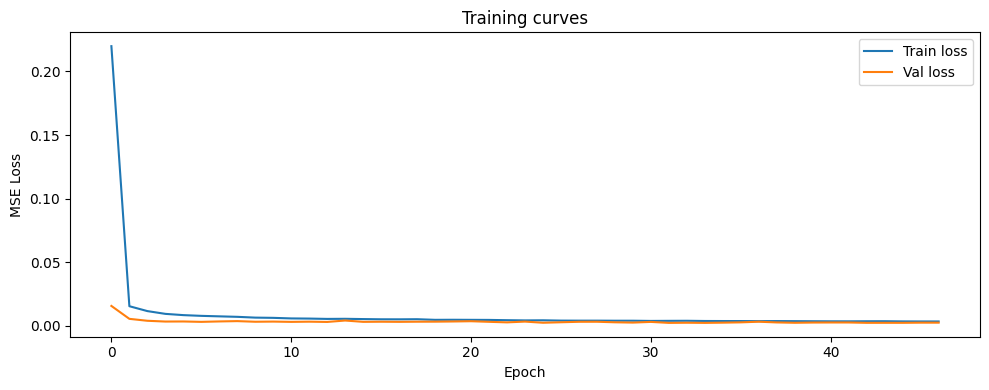

In [68]:
# Plot training curves
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train loss')
plt.plot(val_losses,   label='Val loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training curves')
plt.legend()
plt.tight_layout()
plt.savefig('02_training_curves.png', dpi=150)
plt.show()

### Step 5 - Compute Reconstruction Errors

Anomaly error should be 10–100× higher than normal error. If the separation ratio is low (< 5×), your model is too expressive (latent dim too large, trained too long, or dropout too low) and is reconstructing anomalies almost as well as normals.

In [69]:
model.eval()
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)

with torch.no_grad():
    X_recon = model(X_test_tensor).cpu().numpy()

# Per-window reconstruction error = mean squared error across all 30 timesteps
recon_errors = np.mean((X_test - X_recon) ** 2, axis=1)

# Sanity check: normal windows should have MUCH lower error than anomaly windows
normal_errors  = recon_errors[y_test == 0]
anomaly_errors = recon_errors[y_test == 1]
print(f'Normal  windows — mean error: {normal_errors.mean():.6f}, '
      f'std: {normal_errors.std():.6f}, max: {normal_errors.max():.6f}')
print(f'Anomaly windows — mean error: {anomaly_errors.mean():.6f}, '
      f'std: {anomaly_errors.std():.6f}, min: {anomaly_errors.min():.6f}')
print(f'\nSeparation ratio: {anomaly_errors.mean() / normal_errors.mean():.1f}x')

Normal  windows — mean error: 0.002179, std: 0.003317, max: 0.054383
Anomaly windows — mean error: 0.343267, std: 0.081790, min: 0.006182

Separation ratio: 157.5x


### Step 6 - Threshold Calibration

In [ ]:
# Method 1: Statistical threshold (mean + k*std of validation errors)
val_tensor = torch.tensor(X_val, dtype=torch.float32).to(DEVICE)
with torch.no_grad():
    val_recon = model(val_tensor).cpu().numpy()
val_errors = np.mean((X_val - val_recon) ** 2, axis=1)

mu, sigma = val_errors.mean(), val_errors.std()
threshold_stat = mu + 3 * sigma

# Method 2: Percentile threshold
threshold_p99 = np.percentile(val_errors, 99)

# Method 3 (best): Maximize F1 over all possible thresholds
# Requires at least a small labeled set — we use our test labels here
precisions, recalls, thresholds_pr = precision_recall_curve(y_test, recon_errors)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-10)
best_idx   = np.argmax(f1_scores)
threshold_f1  = thresholds_pr[best_idx]
best_f1       = f1_scores[best_idx]

print(f'Statistical threshold (μ+3σ):  {threshold_stat:.6f}')
print(f'Percentile threshold (p99):     {threshold_p99:.6f}')
print(f'F1-optimal threshold:           {threshold_f1:.6f}  →  F1 = {best_f1:.4f}')

# AUROC — threshold-independent measure of discriminative ability
auroc = roc_auc_score(y_test, recon_errors)
auprc = auc(recalls, precisions)
print(f'\nAUROC: {auroc:.4f}')
print(f'AUPRC: {auprc:.4f}')

Statistical threshold (μ+3σ):  0.015844
Percentile threshold (p99):     0.030435
F1-optimal threshold:           0.055235  →  F1 = 0.9857

AUROC: 0.9998
AUPRC: 0.9986


### Step 7 - Final Evaluation

In [72]:
# Apply the F1-optimal threshold
y_pred = (recon_errors > threshold_f1).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print('Classification Report:')
print(classification_report(y_test, y_pred,
                             target_names=['Normal', 'Anomaly']))

cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(f'  TN={cm[0,0]}  FP={cm[0,1]}')
print(f'  FN={cm[1,0]}  TP={cm[1,1]}')
print(f'\nFalse Positive Rate: {cm[0,1] / (cm[0,0] + cm[0,1]):.4f}')
print(f'False Negative Rate: {cm[1,0] / (cm[1,0] + cm[1,1]):.4f}')

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      3506
     Anomaly       1.00      0.97      0.98       497

    accuracy                           1.00      4003
   macro avg       1.00      0.98      0.99      4003
weighted avg       1.00      1.00      1.00      4003

Confusion Matrix:
  TN=3506  FP=0
  FN=15  TP=482

False Positive Rate: 0.0000
False Negative Rate: 0.0302


### Visualize everything

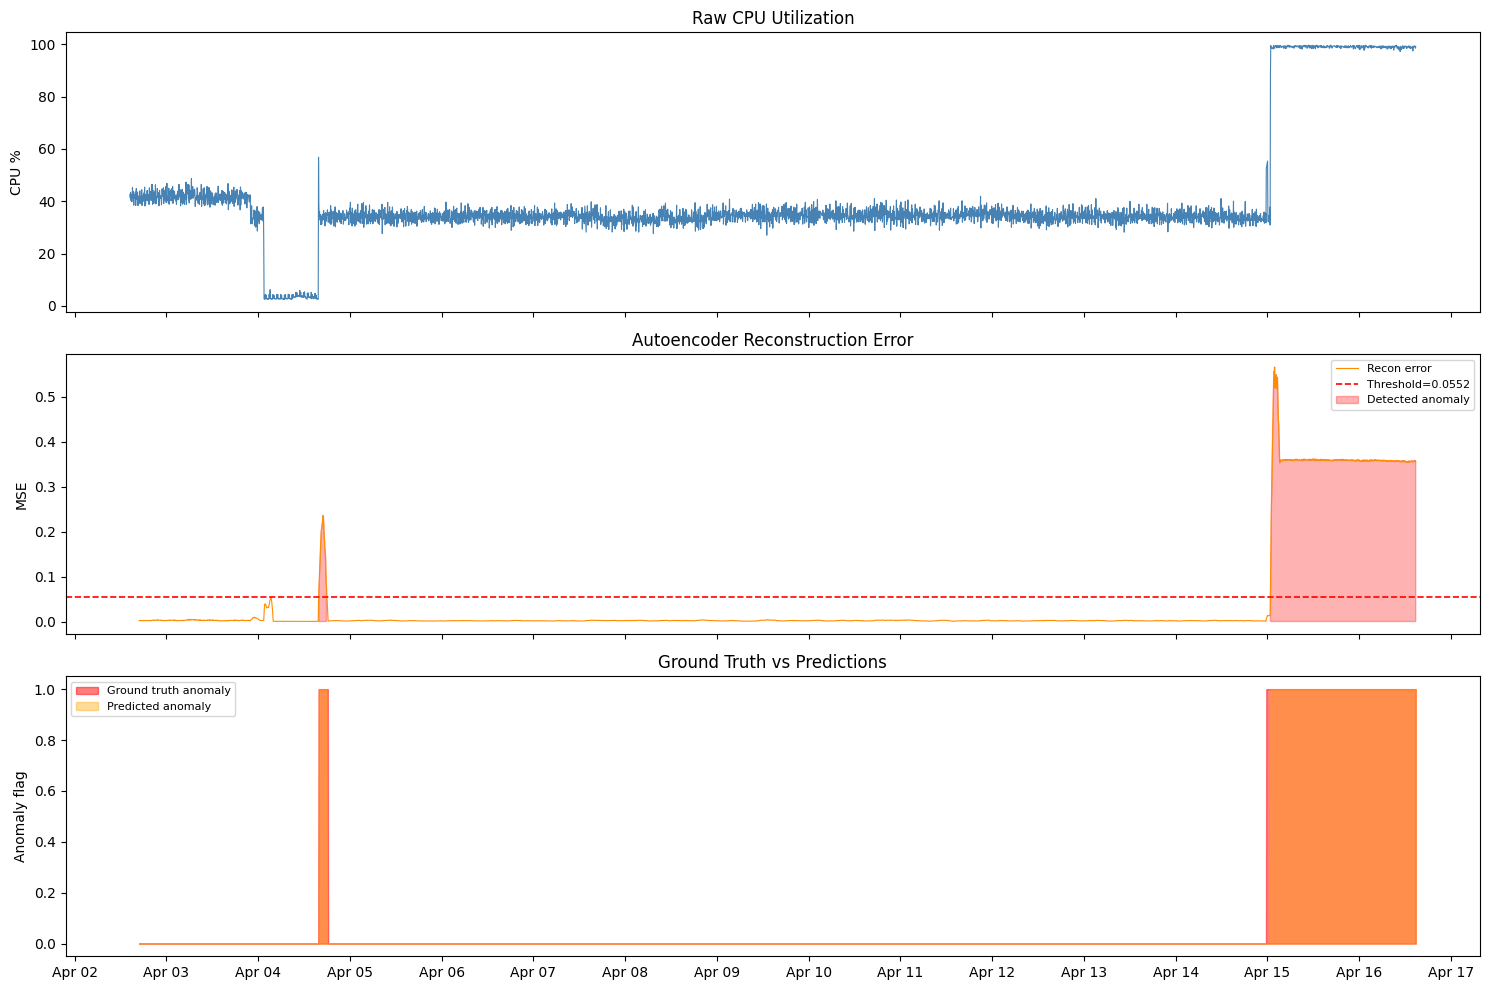

In [75]:
# Reconstruct the timeline of anomaly scores
# Each window maps to its LAST timestamp (the most recent point in the window)
window_times = df['timestamp'].values[WINDOW_SIZE - 1:]

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

# Panel 1: Raw series
axes[0].plot(df['timestamp'], df['value'], color='steelblue', lw=0.8)
axes[0].set_ylabel('CPU %')
axes[0].set_title('Raw CPU Utilization')

# Panel 2: Reconstruction error over time
axes[1].plot(window_times, recon_errors, color='darkorange', lw=0.8, label='Recon error')
axes[1].axhline(threshold_f1, color='red', linestyle='--', lw=1.2, label=f'Threshold={threshold_f1:.4f}')
axes[1].fill_between(window_times, 0, recon_errors,
                      where=(recon_errors > threshold_f1),
                      color='red', alpha=0.3, label='Detected anomaly')
axes[1].set_ylabel('MSE')
axes[1].set_title('Autoencoder Reconstruction Error')
axes[1].legend(fontsize=8)

# Panel 3: Ground truth vs predictions
axes[2].fill_between(window_times, 0, y_test,
                      color='red', alpha=0.5, label='Ground truth anomaly')
axes[2].fill_between(window_times, 0, y_pred,
                      color='orange', alpha=0.4, label='Predicted anomaly')
axes[2].set_ylabel('Anomaly flag')
axes[2].set_title('Ground Truth vs Predictions')
axes[2].legend(fontsize=8)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.DayLocator())

plt.tight_layout()
plt.savefig('03_results.png', dpi=150)
plt.show()

Three things stand out:

1. **The spike around Apr 4–5** : the reconstruction error briefly shoots up to 0.24 (crosses the threshold momentarily). Looking at the raw CPU panel, there's a brief sharp spike there too, a real transient event. The model caught it but it wasn't in the ground truth labels, meaning it's either an unlabelled anomaly or a genuine edge case.
2. **The main anomaly from Apr 15** : reconstruction error explodes to 0.55 at the onset, then settles at ~0.35 for the entire duration. The model detects it cleanly and continuously.
3. **The ground truth vs predictions panel** : the orange (predicted) aligns almost perfectly with the red (ground truth) for the main anomaly. The only mismatch is those 15 missed windows at the very beginning of the spike, the first few windows still contained mostly normal timesteps from before the spike started, so reconstruction error hadn't fully crossed the threshold yet. That's expected window-boundary behaviour.